# NLP & representation learning: Neural Embeddings, Text Classification


To use statistical classifiers with text, it is first necessary to vectorize the text. In the first practical session we explored the **Bag of Word (BoW)** model.

Modern **state of the art** methods uses  embeddings to vectorize the text before classification in order to avoid feature engineering.

## [Dataset](https://thome.isir.upmc.fr/classes/RITAL/json_pol.json)


## "Modern" NLP pipeline

By opposition to the **bag of word** model, in the modern NLP pipeline everything is **embeddings**. Instead of encoding a text as a **sparse vector** of length $D$ (size of feature dictionnary) the goal is to encode the text in a meaningful dense vector of a small size $|e| <<< |D|$.


The raw classification pipeline is then the following:

```
raw text ---|embedding table|-->  vectors --|Neural Net|--> class
```


### Using a  language model:

How to tokenize the text and extract a feature dictionnary is still a manual task. To directly have meaningful embeddings, it is common to use a pre-trained language model such as `word2vec` which we explore in this practical.

In this setting, the pipeline becomes the following:
```
      
raw text ---|(pre-trained) Language Model|--> vectors --|classifier (or fine-tuning)|--> class
```


- #### Classic word embeddings

 - [Word2Vec](https://arxiv.org/abs/1301.3781)
 - [Glove](https://nlp.stanford.edu/projects/glove/)


- #### bleeding edge language models techniques (see next)

 - [UMLFIT](https://arxiv.org/abs/1801.06146)
 - [ELMO](https://arxiv.org/abs/1802.05365)
 - [GPT](https://blog.openai.com/language-unsupervised/)
 - [BERT](https://arxiv.org/abs/1810.04805)






### Goal of this session:

1. Train word embeddings on training dataset
2. Tinker with the learnt embeddings and see learnt relations
3. Tinker with pre-trained embeddings.
4. Use those embeddings for classification
5. Compare different embedding models

## STEP 0: Loading data

In [1]:
import json
from collections import Counter

# Loading json
file = './datasets/json_pol.json'
with open(file,encoding="utf-8") as f:
    data = json.load(f)


# Quick Check
counter = Counter((x[1] for x in data))
print("Number of reviews : ", len(data))
print("----> # of positive : ", counter[1])
print("----> # of negative : ", counter[0])
print("")
print(data[0])

Number of reviews :  25000
----> # of positive :  12500
----> # of negative :  12500

['Although credit should have been given to Dr. Seuess for stealing the story-line of "Horton Hatches The Egg", this was a fine film. It touched both the emotions and the intellect. Due especially to the incredible performance of seven year old Justin Henry and a script that was sympathetic to each character (and each one\'s predicament), the thought provoking elements linger long after the tear jerking ones are over. Overall, superior acting from a solid cast, excellent directing, and a very powerful script. The right touches of humor throughout help keep a "heavy" subject from becoming tedious or difficult to sit through. Lastly, this film stands the test of time and seems in no way dated, decades after it was released.', 1]


## Word2Vec: Quick Recap

**[Word2Vec](https://arxiv.org/abs/1301.3781) is composed of two distinct language models (CBOW and SG), optimized to quickly learn word vectors**


given a random text: `i'm taking the dog out for a walk`



### (a) Continuous Bag of Word (CBOW)
    -  predicts a word given a context
    
maximizing `p(dog | i'm taking the ___ out for a walk)`
    
### (b) Skip-Gram (SG)               
    -  predicts a context given a word
    
 maximizing `p(i'm taking the out for a walk | dog)`



   

NOTE: SG is more robust but requires more data

## STEP 1: train a language model (word2vec)

Gensim has one of [Word2Vec](https://radimrehurek.com/gensim/models/word2vec.html) fastest implementation.


### Train:

In [ ]:
# if gensim not installed yet
# ! pip install gensim

In [2]:
import gensim
import logging
logging.basicConfig(format='%(asctime)s : %(levelname)s : %(message)s', level=logging.INFO)

text = [t.split() for t,p in data]

# the following configuration is the default configuration
w2v = gensim.models.word2vec.Word2Vec(sentences=text,
                                vector_size=100, window=5,               ### here we train a cbow model
                                min_count=5,
                                sample=0.001, workers=3,
                                sg=1, hs=0, negative=5,        ### set sg to 1 to train a sg model
                                cbow_mean=1, epochs=5)

2026-02-16 13:32:02,697 : INFO : collecting all words and their counts
2026-02-16 13:32:02,697 : INFO : PROGRESS: at sentence #0, processed 0 words, keeping 0 word types
2026-02-16 13:32:02,906 : INFO : PROGRESS: at sentence #10000, processed 2301366 words, keeping 153853 word types
2026-02-16 13:32:03,139 : INFO : PROGRESS: at sentence #20000, processed 4553558 words, keeping 240043 word types
2026-02-16 13:32:03,264 : INFO : collected 276678 word types from a corpus of 5713167 raw words and 25000 sentences
2026-02-16 13:32:03,264 : INFO : Creating a fresh vocabulary
2026-02-16 13:32:03,360 : INFO : Word2Vec lifecycle event {'msg': 'effective_min_count=5 retains 48208 unique words (17.42% of original 276678, drops 228470)', 'datetime': '2026-02-16T13:32:03.360537', 'gensim': '4.4.0', 'python': '3.10.19 (main, Oct 21 2025, 16:37:10) [Clang 20.1.8 ]', 'platform': 'macOS-26.2-arm64-arm-64bit', 'event': 'prepare_vocab'}
2026-02-16 13:32:03,360 : INFO : Word2Vec lifecycle event {'msg': 'ef

In [3]:
# Worth it to save the previous embedding
w2v.save("W2v-movies.dat")
# You will be able to reload them:
# w2v = gensim.models.Word2Vec.load("W2v-movies.dat")
# and you can continue the learning process if needed

2026-02-16 13:36:56,377 : INFO : Word2Vec lifecycle event {'fname_or_handle': 'W2v-movies.dat', 'separately': 'None', 'sep_limit': 10485760, 'ignore': frozenset(), 'datetime': '2026-02-16T13:36:56.377206', 'gensim': '4.4.0', 'python': '3.10.19 (main, Oct 21 2025, 16:37:10) [Clang 20.1.8 ]', 'platform': 'macOS-26.2-arm64-arm-64bit', 'event': 'saving'}
2026-02-16 13:36:56,379 : INFO : not storing attribute cum_table
2026-02-16 13:36:56,418 : INFO : saved W2v-movies.dat


## STEP 2: Test learnt embeddings

The word embedding space directly encodes similarities between words: the vector coding for the word "great" will be closer to the vector coding for "good" than to the one coding for "bad". Generally, [cosine similarity](https://en.wikipedia.org/wiki/Cosine_similarity) is the distance used when considering distance between vectors.

KeyedVectors have a built in [similarity](https://radimrehurek.com/gensim/models /keyedvectors.html#gensim.models.keyedvectors.BaseKeyedVectors.similarity) method to compute the cosine similarity between words

In [8]:
# is great really closer to good than to bad ?
print("great and good:",w2v.wv.similarity("great","good"))
print("great and bad:",w2v.wv.similarity("great","bad"))

great and good: 0.7709376
great and bad: 0.50726855


Since cosine distance encodes similarity, neighboring words are supposed to be similar. The [most_similar](https://radimrehurek.com/gensim/models/keyedvectors.html#gensim.models.keyedvectors.BaseKeyedVectors.most_similar) method returns the `topn` words given a query.

In [11]:
# The query can be as simple as a word, such as "movie"

# Try changing the word
w2v.wv.most_similar("movie",topn=5) # 5 most similar words
#w2v.wv.most_similar("awesome",topn=5)
#w2v.wv.most_similar("actor",topn=5)

[('film', 0.9284956455230713),
 ('"movie"', 0.8239619135856628),
 ('flick', 0.7813521027565002),
 ('movie,', 0.770396888256073),
 ('"film"', 0.7610387206077576)]

But it can be a more complicated query
Word embedding spaces tend to encode much more.

The most famous exemple is: `vec(king) - vec(man) + vec(woman) => vec(queen)`

In [20]:
# What is awesome - good + bad ?
w2v.wv.most_similar(positive=["awesome","bad"],negative=["good"],topn=3)

#w2v.wv.most_similar(positive=["actor","woman"],negative=["man"],topn=3) # do the famous exemple works for actor ?


# Try other things like plurals for exemple.

[('awful', 0.7671815752983093),
 ('horrible', 0.6573083996772766),
 ('terrible', 0.6533783674240112)]

**To test learnt "synctactic" and "semantic" similarities, Mikolov et al. introduced a special dataset containing a wide variety of three way similarities.**

**You can download the dataset [here](https://thome.isir.upmc.fr/classes/RITAL/questions-words.txt).**

In [22]:
out = w2v.wv.evaluate_word_analogies("datasets/questions-words.txt",case_insensitive=True)  #original semantic syntactic dataset.

2026-02-16 13:47:09,047 : INFO : Evaluating word analogies for top 300000 words in the model on datasets/questions-words.txt
2026-02-16 13:47:09,335 : INFO : capital-common-countries: 10.0% (9/90)
2026-02-16 13:47:09,462 : INFO : Skipping invalid line #3399 in datasets/questions-words.txt
2026-02-16 13:47:09,474 : INFO : capital-world: 3.0% (1/33)
2026-02-16 13:47:09,483 : INFO : Quadruplets with out-of-vocabulary words: 96.4%
2026-02-16 13:47:09,503 : INFO : NB: analogies containing OOV words were skipped from evaluation! To change this behavior, use "dummy4unknown=True"
2026-02-16 13:47:09,544 : INFO : Total accuracy: 8.1% (10/123)


**When training the w2v models on the review dataset, since it hasn't been learnt with a lot of data, it does not perform very well.**


## Word2vec visualisation

In [42]:
# from sklearn.manifold import TSNE
# tsne = TSNE(n_components=2)
# w2v_tsne = tsne.fit_transform(w2v.wv.vectors)
import numpy as np
# np.save("w2v_tsne",w2v_tsne)
w2v_tsne = np.load("w2v_tsne.npy")

In [ ]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
w2v_pca = pca.fit_transform(w2v.wv.vectors)

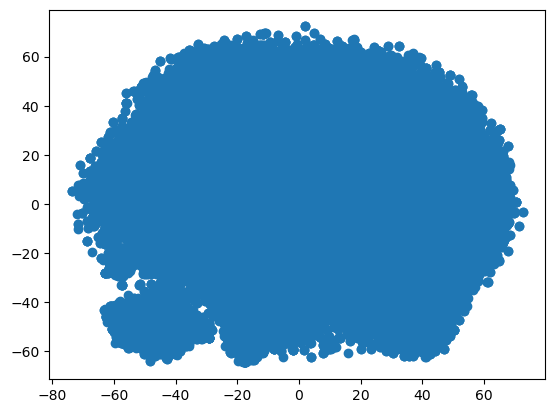

In [49]:
import matplotlib.pyplot as plt
plt.scatter(w2v_tsne[:,0],w2v_tsne[:,1])
plt.show()

## STEP 3: Loading a pre-trained model

In Gensim, embeddings are loaded and can be used via the ["KeyedVectors"](https://radimrehurek.com/gensim/models/keyedvectors.html) class

> Since trained word vectors are independent from the way they were trained (Word2Vec, FastText, WordRank, VarEmbed etc), they can be represented by a standalone structure, as implemented in this module.

>The structure is called “KeyedVectors” and is essentially a mapping between entities and vectors. Each entity is identified by its string id, so this is a mapping between {str => 1D numpy array}.

>The entity typically corresponds to a word (so the mapping maps words to 1D vectors), but for some models, they key can also correspond to a document, a graph node etc. To generalize over different use-cases, this module calls the keys entities. Each entity is always represented by its string id, no matter whether the entity is a word, a document or a graph node.

**You can download the pre-trained word embedding [HERE](https://thome.isir.upmc.fr/classes/RITAL/word2vec-google-news-300.dat) .**

In [56]:
#from gensim.test.utils import get_tmpfile
import gensim.downloader as api
from gensim.models import KeyedVectors
bload = False
fname = "word2vec-google-news-300"
sdir = "datasets/" # Change

if(bload==True):
    wv_pre_trained = KeyedVectors.load(sdir+fname+".dat")
else:
    # wv_pre_trained = api.load(fname)
    wv_pre_trained.save(sdir+fname+".dat")


2026-02-16 15:52:30,918 : INFO : KeyedVectors lifecycle event {'fname_or_handle': 'datasets/word2vec-google-news-300.dat', 'separately': 'None', 'sep_limit': 10485760, 'ignore': frozenset(), 'datetime': '2026-02-16T15:52:30.918130', 'gensim': '4.4.0', 'python': '3.10.19 (main, Oct 21 2025, 16:37:10) [Clang 20.1.8 ]', 'platform': 'macOS-26.2-arm64-arm-64bit', 'event': 'saving'}
2026-02-16 15:52:30,919 : INFO : storing np array 'vectors' to datasets/word2vec-google-news-300.dat.vectors.npy
2026-02-16 15:52:32,991 : INFO : saved datasets/word2vec-google-news-300.dat


**Perform the "synctactic" and "semantic" evaluations again. Conclude on the pre-trained embeddings.**

In [109]:
wv_pre_trained.most_similar(positive=["Hitler", "Italy"], negative=["Germany"])

[('Mussolini', 0.7039323449134827),
 ('Benito_Mussolini', 0.6242587566375732),
 ('Il_Duce', 0.582169234752655),
 ('Adolf_Hitler', 0.5520036816596985),
 ('Fascist', 0.5474885702133179),
 ('dictator_Benito_Mussolini', 0.5351643562316895),
 ('Adolph_Hitler', 0.5342167019844055),
 ('Sicily', 0.5271466374397278),
 ('Sicilian', 0.5181462168693542),
 ('fascist_dictator_Benito', 0.5155349373817444)]

In [72]:
out = wv_pre_trained.evaluate_word_analogies("datasets/questions-words.txt",case_insensitive=True) 

2026-02-16 16:09:51,188 : INFO : Evaluating word analogies for top 300000 words in the model on datasets/questions-words.txt
2026-02-16 16:09:58,070 : INFO : capital-common-countries: 83.2% (421/506)
2026-02-16 16:10:28,749 : INFO : Skipping invalid line #3399 in datasets/questions-words.txt
2026-02-16 16:10:28,756 : INFO : capital-world: 80.8% (2245/2780)
2026-02-16 16:10:28,773 : INFO : Quadruplets with out-of-vocabulary words: 3.3%
2026-02-16 16:10:28,786 : INFO : NB: analogies containing OOV words were skipped from evaluation! To change this behavior, use "dummy4unknown=True"
2026-02-16 16:10:28,801 : INFO : Total accuracy: 81.1% (2666/3286)


## STEP 4:  sentiment classification

In the previous practical session, we used a bag of word approach to transform text into vectors.
Here, we propose to try to use word vectors (previously learnt or loaded).


### <font color='green'> Since we have only word vectors and that sentences are made of multiple words, we need to aggregate them. </font>


### (1) Vectorize reviews using word vectors:

Word aggregation can be done in different ways:

- Sum
- Average
- Min/feature
- Max/feature

#### a few pointers:

- `w2v.wv.vocab` is a `set()` of the vocabulary (all existing words in your model)
- `np.minimum(a,b) and np.maximum(a,b)` respectively return element-wise min/max

In [116]:
import os

def load_movies(path): # 1 classe par répertoire
    texts = [] # init vide
    labels = []
    for dir_name in os.listdir(path): # parcours des fichiers d'un répertoire
        if dir_name in ["pos", "neg"]:
            for file_name in os.listdir(path+dir_name):
                txt = open(path+dir_name+'/'+file_name).read()
                texts.append(txt)
                labels.append( 1 if dir_name == "pos" else 0) 

    return texts,labels

texts_mov, labels_mov = load_movies("./Dataset/movies1000/")
# train = [ (["Hitler", "Putin"],1), (["Hitler", "Putin"],1)]
# test = [ (["Hitler", "Putin"],1), (["Hitler", "Putin"],1)]

In [118]:
train_prop = 0.8
n = len(texts_mov)
indicies = np.arange(n)
np.random.shuffle(indicies)
train_size = int(n * train_prop)
train_idx = indicies[:train_size]
test_idx = indicies[train_size:]

train = [ (texts_mov[i].split(), labels_mov[i]) for i in range(n) if i in train_idx]
test = [ (texts_mov[i].split(), labels_mov[i]) for i in range(n) if i in test_idx]

In [120]:
import numpy as np
# We first need to vectorize text:
# First we propose to a sum of them


def vectorize(text,mean=False):
    """
    This function should vectorize one review

    input: str
    output: np.array(float)
    """
    vec = np.zeros(wv_pre_trained.vector_size)
    for word in text:
        if word in wv_pre_trained.key_to_index:
            idx = wv_pre_trained.key_to_index[word]
            vec += wv_pre_trained.vectors[idx]
    if mean:
        vec = vec / len(text)
        
    return vec


classes = [pol for text,pol in train]
X = [vectorize(text) for text,pol in train]
X_test = [vectorize(text) for text,pol in test]
true = [pol for text,pol in test]

#let's see what a review vector looks like.
print(X[0])

[ 3.99758730e+01  2.22197323e+01  1.87116013e+01  9.17010880e+01
 -5.24128253e+01 -4.40644073e+00  2.94220428e+01 -6.62949829e+01
  5.84526472e+01  6.99059014e+01 -3.38774719e+01 -1.23573433e+02
 -2.39659433e+01  1.52818079e+01 -9.53459396e+01  5.32944145e+01
  5.95065918e+01  7.16039042e+01 -5.39168358e-01 -5.98602161e+01
 -1.29873829e+01  5.72498970e+01  1.44904411e+01 -1.63362389e+01
  5.30201702e+01 -1.23788729e+01 -7.10057874e+01  5.24439125e+01
  2.30387615e+01  1.11798906e+01 -3.31463287e+01  2.47686539e+01
 -2.83909521e+01  1.67179489e+00  2.88595695e+01 -4.49327087e+00
  3.11684818e+01  2.82622719e+00  4.01174474e+01  6.68499794e+01
  9.15636683e+01 -4.15664139e+01  9.69755239e+01 -1.99413767e+01
 -1.13122787e+01 -5.84391177e+00 -2.34599474e+01  6.56773853e+00
  4.58810120e+01  1.33358111e+01 -3.91671181e+00  3.32853241e+01
 -1.48847675e+01 -7.67484283e+00 -2.68430424e+00  2.49029999e+01
 -9.95550919e+00 -4.90686054e+01  3.10292234e+01 -5.63588982e+01
 -1.35673447e+01  7.79491

### (2) Train a classifier
as in the previous practical session, train a logistic regression to do sentiment classification with word vectors



Accuracy: 0.785


/Users/vlad/miniconda3/envs/rital/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


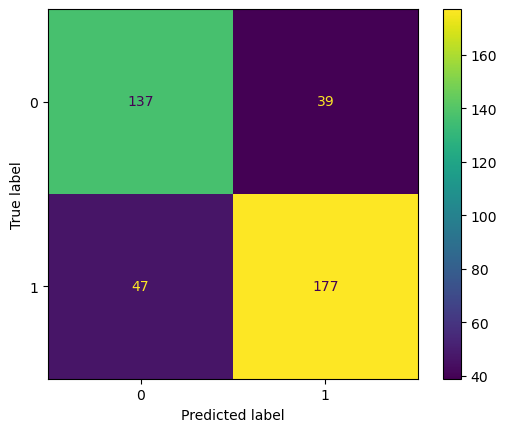

In [132]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay

# Scikit Logistic Regression

logreg = LogisticRegression("l2")

logreg.fit(X, classes)
y_pred = logreg.predict(X_test)

print( f"Accuracy: {accuracy_score(true, y_pred)}" )

ConfusionMatrixDisplay.from_predictions(true, y_pred)

performance should be worst than with bag of word (~80%). Sum/Mean aggregation does not work well on long reviews (especially with many frequent words). This adds a lot of noise.

## **Todo**:  Try answering the following questions:

- Which word2vec model works best: skip-gram or cbow
- Do pretrained vectors work best than those learnt on the train dataset ?

## **Todo**: evaluate the same pipeline on speaker ID task (Chirac/Mitterrand)


**(Bonus)** To have a better accuracy, we could try two things:
- Better aggregation methods (weight by tf-idf ?)
- Another word vectorizing method such as [fasttext](https://radimrehurek.com/gensim/models/fasttext.html)
- A document vectorizing method such as [Doc2Vec](https://radimrehurek.com/gensim/models/doc2vec.html)